# Oracle tuning & calibration — with AutoEIS EIS + ECM

This notebook calibrates a `PyBaMMOracle` to target EIS/capacity behaviour using
the **real AutoEIS Bayesian ECM fit** (`_autoeis_ecm`), not the fast Randles stub.

> **Runtime / requirements.** This notebook is **slow** (PyBaMM SPMe cycles +
> AutoEIS/NumPyro Bayesian inference + an Optuna search). It needs the extras:
>
> ```bash
> uv sync --extra autoeis --extra tune
> ```
>
> It is committed with outputs pre-rendered and is **not** executed in CI or on
> the docs builder. Re-run it manually to refresh the figures.

**What it shows**
1. One real EIS spectrum from AutoEIS's own bundled battery-cycling dataset,
   fit with AutoEIS (Nyquist + posterior).
2. A calibration against that same real dataset: fit a subsample of its cycles to
   get target arc-ratio / R1-growth metrics, then search for degradation scales that
   reproduce them. §3–§8 build that search **by hand** — a two-objective NSGA-II loop
   over `run_oracle_candidate` — to expose the mechanics of what the engine automates.
3. Deeper diagnostics — EIS before/after tuning, the Optuna Pareto frontier, the
   convergence trace, and how the **degradation-mechanism mix** shifts during tuning.
4. §9 then runs the **shipped one-call engine** (`calibrate_oracle`) end-to-end on the
   same data: a process-parallel search (`n_jobs>1`), the config + calibration-summary
   sidecars, and the built-in `tune_plots` figures.


In [1]:
import os

# Silence AutoEIS/tqdm progress bars. TQDM_DISABLE (set before `import autoeis`)
# disables the plain-text tqdm the process-parallel tuning workers use; the ipywidgets
# variant the Jupyter kernel uses is not caught by it and is handled by the monkeypatch
# just below the autoeis import. Together they keep the per-fit "Running Bayesian
# Inference" bars out of the notebook (they otherwise flood it and bloat the saved file).
os.environ["TQDM_DISABLE"] = "1"

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
import autoeis as ae

# AutoEIS's per-fit "Running Bayesian Inference" bar (autoeis/core.py:717) ignores its
# own progress_bar=False argument, and in the kernel it is the ipywidgets tqdm that
# TQDM_DISABLE does not catch. Repoint the tqdm AutoEIS bound at import time to a
# disabled one so those bars are never created.
import functools as _functools
from tqdm.std import tqdm as _tqdm_std
import autoeis.core as _ae_core
import autoeis.utils as _ae_utils
_silent_tqdm = _functools.partial(_tqdm_std, disable=True)
_ae_core.tqdm = _silent_tqdm
_ae_utils.tqdm = _silent_tqdm

from battery_oracle import (
    PyBaMMOracle, make_pybamm_candidates, compute_real_targets,
    write_oracle_config, load_default_ecm_circuit,
    calibrate_oracle, write_calibration_summary,
    plot_eis_comparison,
)
from battery_oracle.oracle import _autoeis_ecm, _AUTOEIS_AVAILABLE
# print_summary and collect_eis_comparison are engine internals (not re-exported
# at the package top level), so import them from the submodule.
from battery_oracle.tune import (
    run_oracle_candidate, print_summary, collect_eis_comparison, _suggest_scales,
)
from battery_oracle.tune_plots import (
    plot_pareto_front, plot_optimization_history, plot_alignment_summary,
)
from battery_oracle._plotting import slipstream, label_axes

optuna.logging.set_verbosity(optuna.logging.WARNING)

assert _AUTOEIS_AVAILABLE, "This notebook needs the [autoeis] extra: uv sync --extra autoeis --extra tune"

plt.rcParams.update({"font.family": "serif", "figure.dpi": 120, "axes.grid": True,
                     "grid.alpha": 0.3})

def cmap_colors(n):
    """n evenly spaced Slipstream colours."""
    return [slipstream(i / max(n - 1, 1)) for i in range(n)]

# All generated artifacts (configs, the calibration-summary JSON, sweep_results.csv,
# and the tune_plots PNGs) land here rather than polluting the notebooks/ root.
OUT_DIR = Path("tune_demo_outputs")
OUT_DIR.mkdir(exist_ok=True)

# The ECM structure is NOT assumed here: it is loaded from the YAML config
# (config_oracle_defaults.yml -> ecm.circuit). Every oracle below fits this circuit,
# and the tune engine derives the ohmic/arc-resistor positions from it. It also
# happens to be the exact circuit AutoEIS's own bundled battery dataset (below)
# is fit with in AutoEIS's documentation.
CIRCUIT = load_default_ecm_circuit()
print("ECM circuit (from config):", CIRCUIT)

# EIS noise. The default "combined" model adds 1/f (flicker) noise whose amplitude
# scales as noise_level*|Z|/sqrt(freq) -- it blows up at low frequencies (~10x more
# noise at 0.01 Hz than at 1 Hz). For clean demonstration spectra we use flat
# "white" noise at a modest level; switch to "combined"/"flicker" to see the
# realistic low-frequency scatter, or raise eis.freq_min_hz to drop the noisiest
# decade. See the EIS-noise discussion in the docs.
EIS_NOISE = dict(eis_noise_model="white", eis_noise_level=0.01)


ECM circuit (from config): R1-[R2,P3]-[R4,P5]


## 1. One real EIS spectrum, fit with AutoEIS

`autoeis` ships a real dataset as part of the package itself:
`ae.io.load_battery_dataset()` returns 130 EIS spectra measured on a real coin
cell at the discharged state across cycling — it's AutoEIS's own example
dataset for per-cycle batch inference, and it happens to be fit with the exact
circuit (`R1-[R2,P3]-[R4,P5]`) this project defaults to. The code never hard-codes
that string — it is loaded dynamically via `load_default_ecm_circuit()` (above) and
threaded through every fit. Pull one cycle and fit it with `_autoeis_ecm` directly
(no oracle/PyBaMM involved in this section).


In [2]:
battery_cycles = ae.io.load_battery_dataset()
print(f"AutoEIS bundled battery dataset: {len(battery_cycles)} real coin-cell "
      f"EIS cycles (discharged state)")

freq, Z = battery_cycles[0]
freq = freq.real                 # stored as complex128 with zero imaginary part
Zr, nImZ = Z.real, -Z.imag       # jones2022 Nyquist convention: x=Re Z, y=-Im Z

diag = {}
_autoeis_ecm(freq, Zr, Z.imag, circuit=CIRCUIT, _diag=diag)
print("fitted ECM elements:", diag["ecm_params"])
print("posterior max CV:", diag["max_cv"], " converged:", diag["converged"])


AutoEIS bundled battery dataset: 130 real coin-cell EIS cycles (discharged state)


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

fitted ECM elements: {'elements': ['R1', 'R2', 'P3w', 'P3n', 'R4', 'P5w', 'P5n'], 'values': {'R1': 0.10651129412593607, 'R2': 3.1406981947343917, 'P3w': 32.18510615087929, 'P3n': 0.9847915398607564, 'R4': 1.7541807439918213, 'P5w': 0.09883945423334424, 'P5n': 0.4549118886176736}}
posterior max CV: 1.3744373432742387  converged: True


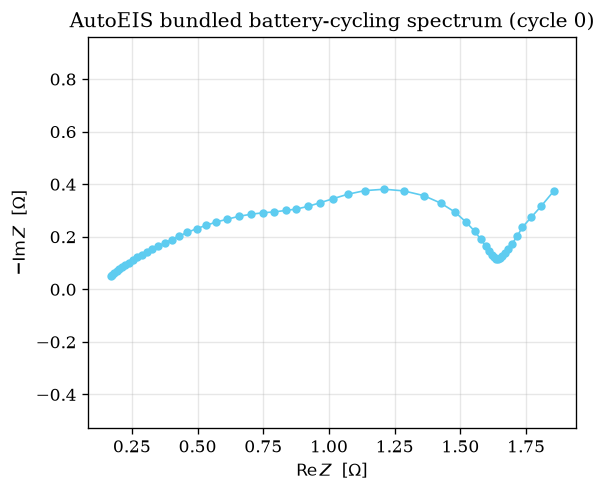

In [3]:
# Nyquist of the real spectrum (jones2022 convention: x=Re Z, y=-Im Z)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(Zr, nImZ, "o-", color=slipstream(0.15), ms=4, lw=1)
ax.set_xlabel(r"$\mathrm{Re}\,Z$  [$\Omega$]")
ax.set_ylabel(r"$-\mathrm{Im}\,Z$  [$\Omega$]")
ax.set_title("AutoEIS bundled battery-cycling spectrum (cycle 0)")
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()


### AutoEIS Bayesian fit + posterior

Refit the same real spectrum directly with `_autoeis_ecm`, keeping the raw MCMC
samples so we can plot the posterior for the key elements.


<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_524197/2667020516.py:15: SyntaxWarning: invalid escape sequence '\O'
  ax.set_title(f"{k} posterior"); ax.set_xlabel(f"{k}  [$\Omega$]")


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

elements: ['R1', 'R2', 'P3w', 'P3n', 'R4', 'P5w', 'P5n']
median values: {'R1': 0.1081, 'R2': 1.7471, 'P3w': 0.0977, 'P3n': 0.4569, 'R4': 2.5329, 'P5w': 31.5925, 'P5n': 0.9825}


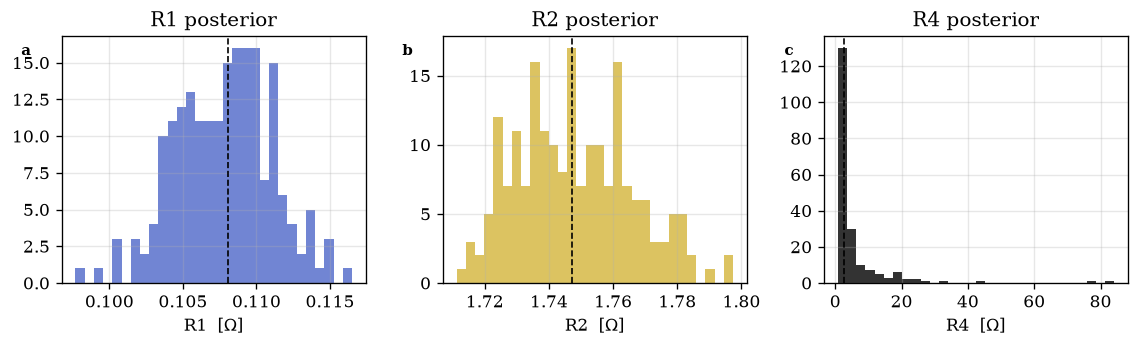

In [4]:
diag = {}
vec, samples, variables = _autoeis_ecm(freq, Zr, -nImZ, _diag=diag, return_samples=True)
elems = diag["ecm_params"]["elements"]
vals = diag["ecm_params"]["values"]
print("elements:", elems)
print("median values:", {k: round(v, 4) for k, v in vals.items()})

# Posterior distributions for the ohmic + charge-transfer resistors
res_keys = [k for k in variables if k.startswith("R")]
cols = cmap_colors(len(res_keys))
fig, axes = plt.subplots(1, len(res_keys), figsize=(3.2 * len(res_keys), 3))
for ax, k, c in zip(np.atleast_1d(axes), res_keys, cols):
    ax.hist(np.asarray(samples[k]), bins=30, color=c, alpha=0.8)
    ax.axvline(np.median(samples[k]), color="k", ls="--", lw=1)
    ax.set_title(f"{k} posterior"); ax.set_xlabel(f"{k}  [$\Omega$]")
label_axes(np.atleast_1d(axes))
plt.tight_layout()


## 2. Real calibration targets from AutoEIS's bundled dataset

An earlier version of this notebook built the calibration cache by replaying
the oracle against itself — a self-consistency demo. That made "recovery"
tautological, and combined badly with a search space that (correctly, for real
cells) excludes the oracle's own default scale: the tuned result ended up
*worse* than doing nothing. Using AutoEIS's own bundled `battery_data.npy`
instead makes this a fit against a **genuine external measurement**.

Fitting all 130 real cycles with full Bayesian AutoEIS inference is too slow
for a demo notebook, so we fit an evenly spaced subsample spanning the first to
the last cycle — enough to see the R1-growth trend — and feed those fits to
`compute_real_targets`. A separate, lightweight cache of synthetic protocols
(`sim_cache`) drives the candidate oracle runs in §3 onward: the real dataset
has measured spectra but no recorded charge/discharge protocol to replay, so
the oracle side still exercises its own representative cycling.


In [5]:
N_REAL_CYCLES = 8
real_idx = np.linspace(0, len(battery_cycles) - 1, N_REAL_CYCLES).astype(int)

real_cache = {"cell_id": "autoeis_battery_dataset", "circuit": CIRCUIT,
              "cycles": [], "data": {}}
for i in real_idx:
    freq_i, Z_i = battery_cycles[int(i)]
    ecm = _autoeis_ecm(freq_i.real, Z_i.real, Z_i.imag, circuit=CIRCUIT)
    key = str(int(i))
    real_cache["cycles"].append(key)
    real_cache["data"][key] = {"ecm_charge": [float(x) for x in ecm]}

targets = compute_real_targets(real_cache)
print(f"fitted {len(real_idx)}/{len(battery_cycles)} real cycles "
      f"(indices {[int(i) for i in real_idx]})")
print("targets (from AutoEIS's real coin-cell dataset):", targets)

# cache carries the circuit so calibrate_oracle/run_oracle_candidate read the
# ECM layout from it rather than assuming a fixed structure.
cands = make_pybamm_candidates(n_candidates=4)
sim_cache = {"real_cell_capacity_mah": 200.0, "circuit": CIRCUIT,
             "cycles": [str(i) for i in range(len(cands))],
             "data": {str(i): {"protocol": [float(x) for x in p]}
                      for i, p in enumerate(cands)}}


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

fitted 8/130 real cycles (indices [0, 18, 36, 55, 73, 92, 110, 129])
targets (from AutoEIS's real coin-cell dataset): {'mean_arc_ratio': 28.097488480843964, 'r1_growth_pct': 48.22443902426426, 'soh_fade_per_cycle': None}


## 3. Multi-objective calibration (NSGA-II)

Arc-ratio error and R1-growth error are **competing** objectives — lowering one can
raise the other — so instead of collapsing them into one weighted score we run a
genuine **multi-objective** optimisation with Optuna's NSGA-II sampler, minimising
both simultaneously over the four degradation scales. The result is a **Pareto
front**: the set of non-dominated trade-off solutions. `n_trials` is modest for
runtime (each trial replays the whole cache through an AutoEIS oracle).


In [ ]:
scale_space = {
    "kinetics_scale":      (0.10, 0.50),
    "sei_rate_scale":      (0.01, 1.00),
    "dead_li_decay_scale": (0.10, 1000.0),
    "plating_rate_scale":  (0.01, 10.0),
}
scale_names = list(scale_space)

# Draw candidates with the engine's own scale sampler (`_suggest_scales`) rather than a
# hand-rolled suggest_float loop, so trials are proposed exactly as `calibrate_oracle`
# proposes them. It takes the bounds as {ks,srs,dds,prs}_{min,max}, so map scale_space
# onto those keys. With no dl_min/dl_max the 5th lever (dod_lam_scale) stays 0.0.
_ABBR = {"kinetics_scale": "ks", "sei_rate_scale": "srs",
         "dead_li_decay_scale": "dds", "plating_rate_scale": "prs"}
RANGES = {}
for _name, (_lo, _hi) in scale_space.items():
    RANGES[f"{_ABBR[_name]}_min"] = _lo
    RANGES[f"{_ABBR[_name]}_max"] = _hi

arc_t = targets["mean_arc_ratio"]; r1_t = targets["r1_growth_pct"]
trial_results = {}   # trial.number -> full run_oracle_candidate dict (for provenance)

def mo_objective(trial):
    ks, srs, dds, prs, _dl = _suggest_scales(trial, RANGES)   # engine's scale sampler
    res = run_oracle_candidate(sim_cache, ks, srs, dds, prs,
                               "accelerated", False, circuit=CIRCUIT)
    trial_results[trial.number] = res
    arc, r1 = res["oracle_arc_ratio"], res["oracle_r1_growth_pct"]
    # Two objectives to MINIMISE simultaneously; large penalty for invalid fits.
    arc_err = abs(arc - arc_t) if arc is not None else 1e3
    r1_err  = abs(r1  - r1_t)  if r1  is not None else 1e3
    return arc_err, r1_err

study = optuna.create_study(
    directions=["minimize", "minimize"],           # <- genuine multi-objective
    sampler=optuna.samplers.NSGAIISampler(seed=42, population_size=8),
)
study.optimize(mo_objective, n_trials=24, show_progress_bar=True)

pareto = study.best_trials                          # Optuna's true non-dominated set
print(f"{len(study.trials)} trials evaluated; {len(pareto)} on the Pareto front")

# A single representative solution: the knee of the front (min L1 of the two
# min-max-normalised objectives). Used for the before/after EIS and the config.
def knee_of(trials):
    V = np.array([t.values for t in trials], float)
    N = (V - V.min(0)) / (np.ptp(V, 0) + 1e-12)
    return trials[int(np.argmin(N.sum(1)))]
knee = knee_of(pareto)
knee_scales = {n: knee.params[n] for n in scale_names}
print("knee scales:", {k: round(v, 4) for k, v in knee_scales.items()},
      " objectives (arc_err, r1_err):", [round(v, 4) for v in knee.values])


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

24 trials evaluated; 5 on the Pareto front
knee scales: {'kinetics_scale': 0.2631, 'sei_rate_scale': 0.1097, 'dead_li_decay_scale': 15.3759, 'plating_rate_scale': 8.1232}  objectives (arc_err, r1_err): [1.2416, 36.81]



hand-rolled knee (NSGA-II, 2 objectives): {'kinetics_scale': 0.2631, 'sei_rate_scale': 0.1097, 'dead_li_decay_scale': 15.3759, 'plating_rate_scale': 8.1232}
package best     (TPE, scalar score)   : {'kinetics_scale': 0.2661, 'sei_rate_scale': 0.4585, 'dead_li_decay_scale': 6.1197, 'plating_rate_scale': 0.7582}
package best score = 1.0052  (arc_ratio=22.26 vs target 28.10; r1_growth=58.3% vs target 48.2%)


In [ ]:

# ── The package's production search on the SAME inputs, for comparison ──
# calibrate_oracle scalarises arc + r1 (+ an EOL plausibility anchor) into ONE score
# and runs single-objective Bayesian TPE -- where the loop above kept arc and r1 as
# two separate NSGA-II objectives. Same sim_cache, same targets, same n_trials, so
# the two search strategies are directly comparable. n_jobs=2 exercises the
# process-parallel path (isolated JAX per worker; see the AutoEIS thread-safety note).
engine_cmp = calibrate_oracle(
    sim_cache, targets, preset="accelerated",
    n_trials=24, n_jobs=2, sampler="tpe", seed=42,
    skip_crate2_slope=True, capacity_check=False,
)
eng_best = engine_cmp["best"]
print("\nhand-rolled knee (NSGA-II, 2 objectives):",
      {k: round(knee_scales[k], 4) for k in scale_names})
print("package best     (TPE, scalar score)   :",
      {k: round(eng_best[k], 4) for k in scale_names})
print(f"package best score = {engine_cmp['best_score']:.4f}  "
      f"(arc_ratio={eng_best['oracle_arc_ratio']:.2f} vs target {arc_t:.2f}; "
      f"r1_growth={eng_best['oracle_r1_growth_pct']:.1f}% vs target {r1_t:.1f}%)")


## 4. EIS spectra before vs after tuning

Run the oracle at the **default** scales `(1,1,1,1)` and at the Pareto **knee**
scales over `sim_cache`'s protocols, and overlay the resulting Nyquist spectra
against a real AutoEIS-measured spectrum. The real coin cell and the
Chen2020-parameterised SPMe are very different cell formats/scales, so each
spectrum is normalised by its own fitted ohmic resistance R1 before plotting —
that's exactly the scale-invariant arc-ratio quantity being calibrated, and it
avoids a meaningless absolute-Ω comparison between an automotive pouch cell and
a coin cell. This is the visual payoff of the calibration.


In [7]:
def run_spectra(scales):
    o = PyBaMMOracle(ecm_model_fn=_autoeis_ecm, degradation_preset="accelerated",
                     capacity_check=False, real_cell_capacity_mah=sim_cache["real_cell_capacity_mah"],
                     circuit=CIRCUIT, **EIS_NOISE, **scales)
    o.reset()
    specs = []
    for key in sim_cache["cycles"]:
        try:
            o(np.array(sim_cache["data"][key]["protocol"]))
        except Exception:
            break
        hh = o._history[-1]
        specs.append((hh["Z_charge_real"], hh["Z_charge_neg_imag"], hh["ecm_params_charge"][0]))
    return specs

default_scales = {n: 1.0 for n in scale_names}
spec_default = run_spectra(default_scales)
spec_tuned = run_spectra(knee_scales)


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

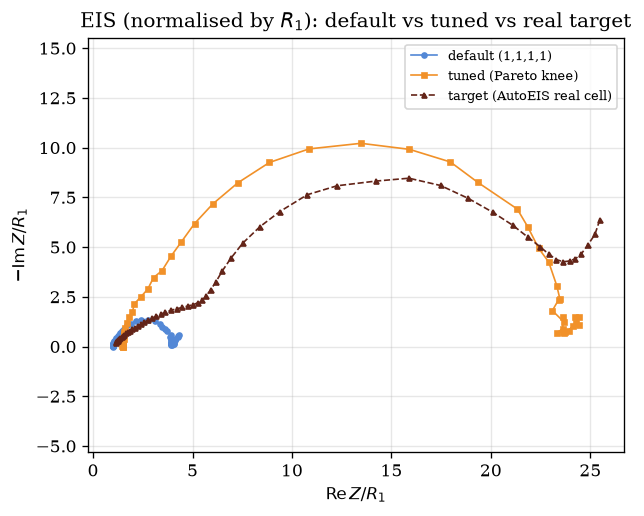

In [8]:
# Overlay the last-cycle Nyquist for default vs tuned-knee, each normalised by
# its own R1 (ohmic resistance), against a real AutoEIS-measured spectrum.
fig, ax = plt.subplots(figsize=(5.4, 4.4))
if spec_default:
    Zr_d, nZi_d, r1_d = spec_default[-1]
    ax.plot(np.array(Zr_d) / r1_d, np.array(nZi_d) / r1_d, "o-", color=slipstream(0.05),
            ms=3, lw=1, label="default (1,1,1,1)")
if spec_tuned:
    Zr_t, nZi_t, r1_tuned = spec_tuned[-1]
    ax.plot(np.array(Zr_t) / r1_tuned, np.array(nZi_t) / r1_tuned, "s-", color=slipstream(0.55),
            ms=3, lw=1, label="tuned (Pareto knee)")

real_key = str(int(real_idx[-1]))
_, Z_real_last = battery_cycles[int(real_idx[-1])]
r1_real = real_cache["data"][real_key]["ecm_charge"][0]     # R1 is element 0 for CIRCUIT
ax.plot(Z_real_last.real / r1_real, -Z_real_last.imag / r1_real, "^--",
        color=slipstream(0.9), ms=3, lw=1, label="target (AutoEIS real cell)")

ax.set_xlabel(r"$\mathrm{Re}\,Z / R_1$"); ax.set_ylabel(r"$-\mathrm{Im}\,Z / R_1$")
ax.set_title("EIS (normalised by $R_1$): default vs tuned vs real target"); ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()


## 5. The real Pareto front

Every trial in the two-objective plane (arc-ratio error vs R1-growth error), with
the **true non-dominated set** returned by NSGA-II (`study.best_trials`) drawn as the
front and the knee marked. Optuna also ships
`optuna.visualization.matplotlib.plot_pareto_front(study)` for the same view.


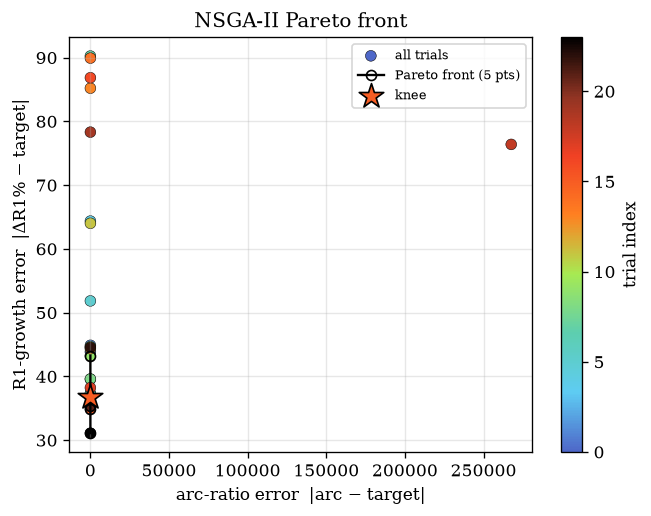

In [9]:
all_v = np.array([t.values for t in study.trials], float)
pf = np.array([t.values for t in pareto], float)
pf = pf[np.argsort(pf[:, 0])]
order = np.array([t.number for t in study.trials])

fig, ax = plt.subplots(figsize=(5.6, 4.4))
sc = ax.scatter(all_v[:, 0], all_v[:, 1], c=order, cmap=slipstream, s=42, edgecolor="k", lw=0.3,
                label="all trials")
ax.plot(pf[:, 0], pf[:, 1], "-o", color="k", lw=1.4, ms=6, mfc="none",
        label=f"Pareto front ({len(pf)} pts)")
ax.scatter([knee.values[0]], [knee.values[1]], marker="*", s=240, color=slipstream(0.65),
           edgecolor="k", zorder=5, label="knee")
ax.set_xlabel("arc-ratio error  |arc − target|")
ax.set_ylabel("R1-growth error  |ΔR1% − target|")
ax.set_title("NSGA-II Pareto front"); ax.legend(fontsize=8)
fig.colorbar(sc, ax=ax, label="trial index")
plt.tight_layout()


## 6. Convergence — hypervolume

For a multi-objective search the natural convergence metric is the **hypervolume**
dominated by the running Pareto front (relative to a fixed reference point): it grows
as the front expands toward the origin. We also show each objective's running best.


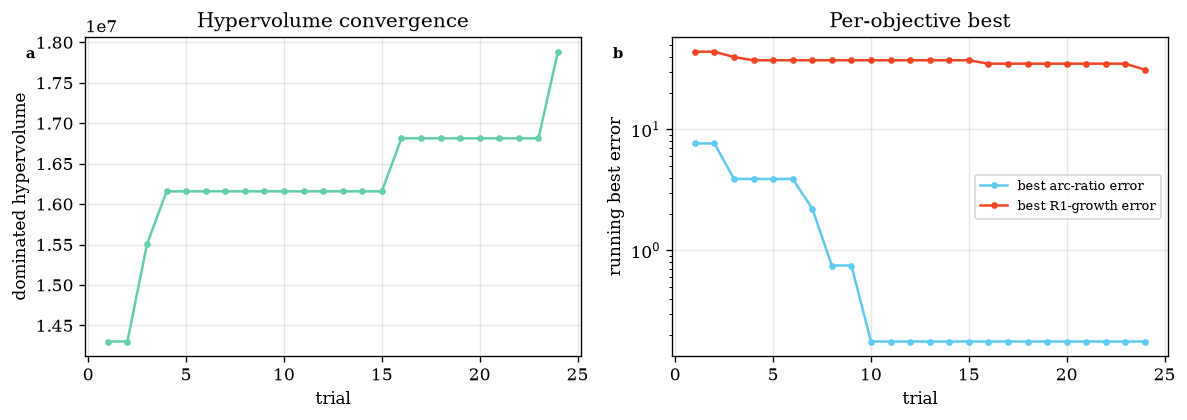

In [10]:
def nondominated(P):
    P = np.asarray(P, float); keep = np.ones(len(P), bool)
    for i, p in enumerate(P):
        if np.any(np.all(P <= p, axis=1) & np.any(P < p, axis=1)):
            keep[i] = False
    return P[keep]

def hv2d(front, ref):
    F = nondominated(front)
    F = F[(F[:, 0] <= ref[0]) & (F[:, 1] <= ref[1])]
    if len(F) == 0:
        return 0.0
    F = F[np.argsort(F[:, 0])]
    xs = np.append(F[:, 0], ref[0]); area = 0.0
    for i in range(len(F)):
        area += (xs[i + 1] - xs[i]) * (ref[1] - F[i, 1])
    return area

ref = all_v.max(0) * 1.05                          # reference point (worst corner)
hv_hist = [hv2d(all_v[:t + 1], ref) for t in range(len(all_v))]
run_min0 = np.minimum.accumulate(all_v[:, 0])
run_min1 = np.minimum.accumulate(all_v[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(range(1, len(hv_hist) + 1), hv_hist, "-o", color=slipstream(0.3), ms=3)
axes[0].set_xlabel("trial"); axes[0].set_ylabel("dominated hypervolume")
axes[0].set_title("Hypervolume convergence")
axes[1].plot(range(1, len(all_v) + 1), run_min0, "-o", ms=3, color=slipstream(0.15),
             label="best arc-ratio error")
axes[1].plot(range(1, len(all_v) + 1), run_min1, "-o", ms=3, color=slipstream(0.7),
             label="best R1-growth error")
axes[1].set_yscale("log"); axes[1].set_xlabel("trial"); axes[1].set_ylabel("running best error")
axes[1].set_title("Per-objective best"); axes[1].legend(fontsize=8)
label_axes(axes)
plt.tight_layout()


## 7. Degradation-mechanism shift across the Pareto front

The trade-off is physical: the arc-ratio-optimal end of the front and the
R1-growth-optimal end reach their fits with a **different mechanism mix**. For the two
front extremes and the knee, re-run the oracle and read the cumulative capacity loss
by mechanism (`cumulative_sei_loss_ah`, `cumulative_plating_ah`,
`cumulative_crack_sei_ah`, `cumulative_dod_lam_ah`).


In [11]:
pf_trials = sorted(pareto, key=lambda t: t.values[0])
picks = {
    "min arc-err": pf_trials[0],
    "knee": knee,
    "min R1-err": pf_trials[-1],
}
mech_keys = ["cumulative_sei_loss_ah", "cumulative_plating_ah",
             "cumulative_crack_sei_ah", "cumulative_dod_lam_ah"]

def mech_series(scales):
    o = PyBaMMOracle(ecm_model_fn=_autoeis_ecm, degradation_preset="accelerated",
                     capacity_check=False, real_cell_capacity_mah=sim_cache["real_cell_capacity_mah"],
                     circuit=CIRCUIT, **{n: scales[n] for n in scale_names})
    o.reset()
    for key in sim_cache["cycles"]:
        try:
            o(np.array(sim_cache["data"][key]["protocol"]))
        except Exception:
            break
    last = o._history[-1] if o._history else {}
    return [abs(last.get(k, 0.0)) for k in mech_keys]


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

...

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

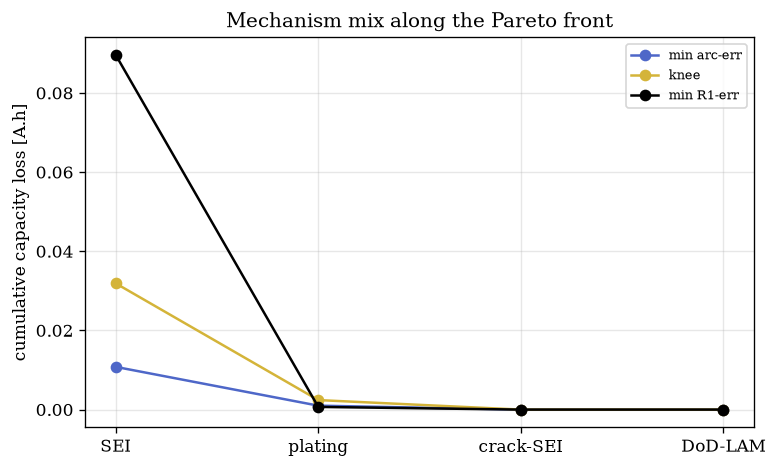

In [12]:

fig, ax = plt.subplots(figsize=(6.6, 4))
labels = ["SEI", "plating", "crack-SEI", "DoD-LAM"]
x = np.arange(len(mech_keys))
cols = cmap_colors(len(picks))
for (name, t), c in zip(picks.items(), cols):
    ax.plot(x, mech_series(t.params), "o-", color=c, label=name)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("cumulative capacity loss [A.h]")
ax.set_title("Mechanism mix along the Pareto front")
ax.legend(fontsize=8)
plt.tight_layout()


## 8. Persist a chosen solution

There is no single "best" in a multi-objective run — the Pareto front is a set of
valid trade-offs. Here we persist the **knee** point (a balanced compromise) with
`write_oracle_config`, passing every trial as provenance.


In [13]:
best_result = trial_results[knee.number]
all_results = [trial_results[t.number] for t in study.trials if t.number in trial_results]
write_oracle_config(OUT_DIR / "config_oracle_demo.yml", "demo", "accelerated", real_cache["cell_id"],
                    len(real_cache["cycles"]), best_result, targets, all_results)
print(f"wrote {OUT_DIR / 'config_oracle_demo.yml'} (knee point of the hand-rolled Pareto front)")


wrote tune_demo_outputs/config_oracle_demo.yml (knee point of the hand-rolled Pareto front)


## 9. The shipped one-call engine: `calibrate_oracle`

§3–§8 built the search by hand to show the mechanics. In practice you call the
packaged engine, which does the same job in one call and adds what the hand-rolled
loop lacks:

- a **process-parallel** search (`n_jobs>1` → `_calibrate_oracle_parallel`): each
  trial runs in its own subprocess with isolated JAX/NumPyro state. AutoEIS's
  Bayesian backend is **not thread-safe** — under a thread pool ~1 in 5 ECM fits
  silently falls back to the analytic Randles stub, biasing the score — so parallelism
  is by process, never threads;
- optional C-rate sensitivity / `C_rate_2` slope probes in the score;
- machine-readable sidecars (`config_oracle_*.yml`, `calibration_summary.json`,
  `sweep_results.csv`) and the built-in `tune_plots` figures.

The engine expects **one** cache carrying both a `protocol` and a ground-truth
`ecm_charge` per cycle (see `docs/calibration.md`). The §1–§8 split of `real_cache`
(ECM only) vs `sim_cache` (protocol only) reflects the AutoEIS demo dataset shipping
no protocol metadata — so here we attach the same mild CC-CV charge to every fitted
real cycle. That is a deliberate simplification: it lets the engine replay-and-score
against the real arc/R1 targets, at the cost of not modelling per-cycle protocol
variation.


In [14]:
# Build the single combined cache the engine expects: protocol + real ECM per cycle.
N_ENGINE_CYCLES = 4
eng_idx = np.linspace(0, len(real_cache["cycles"]) - 1, N_ENGINE_CYCLES).astype(int)
engine_proto = make_pybamm_candidates(n_candidates=1)[0]   # one mild CC-CV charge, reused per cycle

engine_cache = {"cell_id": real_cache["cell_id"], "real_cell_capacity_mah": 200.0,
                "circuit": CIRCUIT, "cycles": [], "data": {}}
for j in eng_idx:
    key = real_cache["cycles"][int(j)]
    engine_cache["cycles"].append(key)
    engine_cache["data"][key] = {
        "protocol": [float(x) for x in engine_proto],
        "ecm_charge": real_cache["data"][key]["ecm_charge"],   # ground truth reused from §2
    }

engine_targets = compute_real_targets(engine_cache)
print("engine cache cycles:", engine_cache["cycles"])
print("engine targets:", engine_targets)


engine cache cycles: ['0', '36', '73', '129']
engine targets: {'mean_arc_ratio': 33.80679854703945, 'r1_growth_pct': 48.22443902426426, 'soh_fade_per_cycle': None}


In [15]:
# One call does the whole search. n_jobs=2 exercises the process-parallel path
# (isolated JAX state per worker); n_trials is kept small for a demo -- each trial
# replays the cache, i.e. one AutoEIS fit per cycle.
engine_out = calibrate_oracle(
    engine_cache, engine_targets,
    preset="accelerated", n_trials=12, n_jobs=2,
    sampler="tpe", seed=42,
    skip_crate2_slope=True, capacity_check=False, show_progress_bar=True,
)
print_summary(engine_out["scored"], engine_out["best"], engine_targets,
              dataset="demo", preset="accelerated", cell_id=engine_cache["cell_id"],
              sampler="tpe", crate_sensitivity_min=3.0, real_crate2_slope=None)

# The newest lever, dod_lam_scale (the C_rate_1 charge-rate LAM knob), stays disabled
# here (engine default 0.0): pass dl_min/dl_max to calibrate_oracle to sweep it. It is
# currently a Python-API argument only -- the battery-oracle-tune CLI does not expose it.



  Calibration BO [TPE] — dataset=demo  preset=accelerated  cell=autoeis_battery_dataset
  Real targets:  arc_ratio=33.81   r1_growth=48.2%   eol_cycle~55
      ks       srs       dds       prs        dl   arc_ratio   r1_growth%   eol_cyc   crate_x    c2_slope     score   eol?
--------------------------------------------------------------------------------------------------------------------------
  0.1693    0.5227     46.17    0.4202         0       42.81        92.5%        98       nan         nan     1.759     no <<
  0.1783    0.1654      3.76    0.1687         0       36.53        75.3%       179       nan         nan     1.820     no
  0.4894    0.7567     27.98    0.0105         0        9.95        15.2%        92       nan         nan     1.910     no
  0.2272    0.2632    695.19    0.2343         0       30.87        98.2%       127       nan         nan     1.958     no
  0.2925    0.9877     17.26    0.9535         0       18.42       -26.1%        77       nan         na

In [16]:
# Persist the three machine-readable sidecars the CLI would write.
engine_cfg = OUT_DIR / "config_oracle_demo_engine.yml"
summary_json = OUT_DIR / "calibration_summary.json"
results_csv = OUT_DIR / "sweep_results.csv"

write_oracle_config(engine_cfg, "demo", "accelerated", engine_cache["cell_id"],
                    len(engine_cache["cycles"]), engine_out["best"], engine_targets,
                    engine_out["results"])
write_calibration_summary(summary_json, dataset="demo", preset="accelerated",
                          cell_id=engine_cache["cell_id"], n_trials=len(engine_out["results"]),
                          n_cycles=len(engine_cache["cycles"]), crate_sensitivity_min=3.0,
                          real_targets=engine_targets, real_crate2_slope=None,
                          best=engine_out["best"], best_score=engine_out["best_score"])
# The engine returns results/scored in memory; tune_plots reads a CSV, so dump it.
pd.DataFrame(engine_out["results"]).to_csv(results_csv, index=False)
print("wrote:", engine_cfg.name, summary_json.name, results_csv.name, "->", OUT_DIR)


wrote: config_oracle_demo_engine.yml calibration_summary.json sweep_results.csv -> tune_demo_outputs


Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

Running Bayesian Inference:   0%|          | 0/1 [00:00<?, ?it/s]

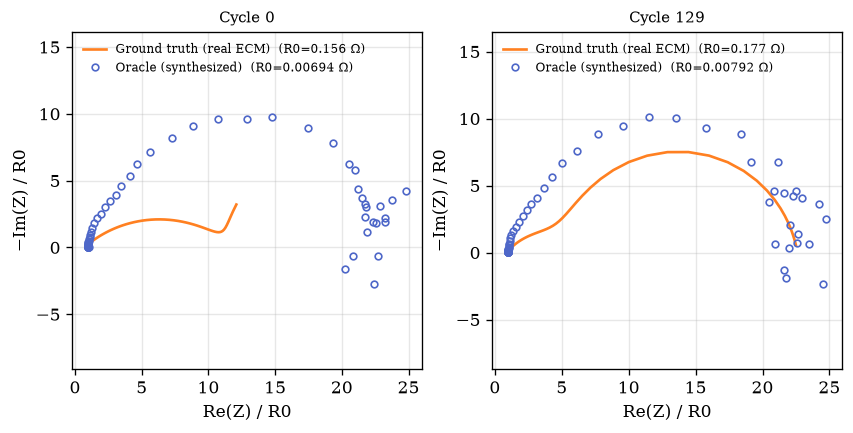

In [17]:
# Oracle-vs-ground-truth EIS for the winning candidate (first + last aged cycle),
# each normalised by its own ohmic R0 -- the same figure the CLI auto-writes.
eis = collect_eis_comparison(engine_cache, engine_out["best"], preset="accelerated",
                             capacity_check=False, circuit=CIRCUIT)
_ = plot_eis_comparison(eis, save_path=OUT_DIR / "oracle_tuning_eis.png")


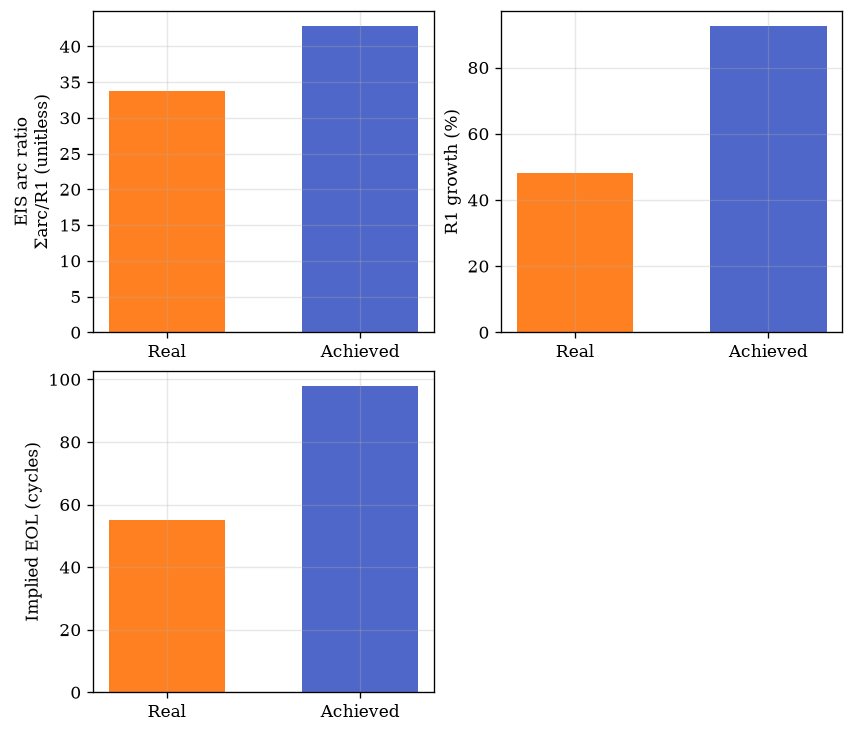

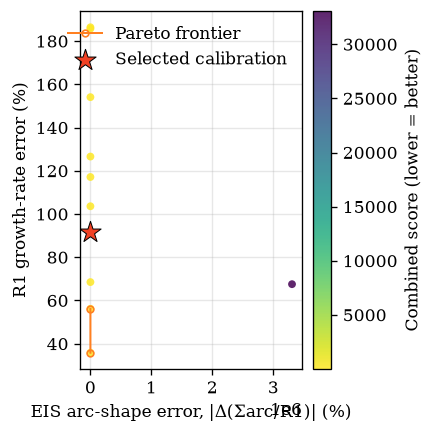

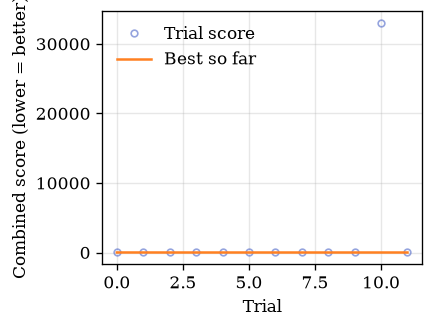

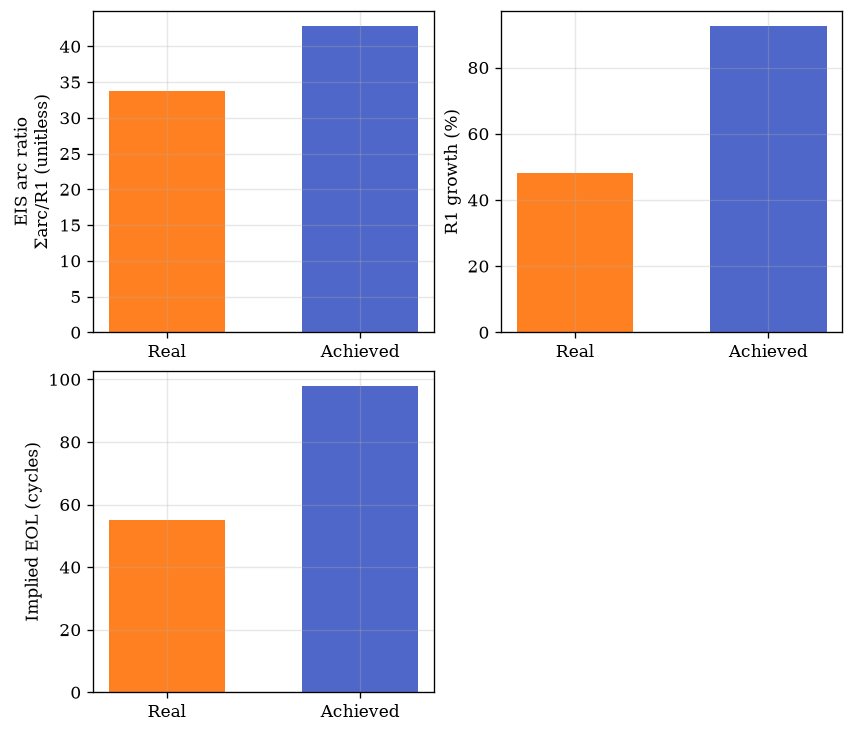

In [18]:
# Render the packaged tuning figures inline with the library's own plotters --
# the Pareto front, the optimisation history, and the real-vs-achieved alignment
# bars -- and save the PNG sidecars the CLI would write. Each plotter returns a
# matplotlib Figure, so no manual image compositing is needed.
results_df = pd.DataFrame(engine_out["results"])
with open(summary_json) as f:
    summary = json.load(f)

plot_pareto_front(results_df, engine_targets, engine_out["best"],
                  save_path=OUT_DIR / "oracle_tuning_pareto.png")
plot_optimization_history(results_df, save_path=OUT_DIR / "oracle_tuning_history.png")
plot_alignment_summary(summary, save_path=OUT_DIR / "oracle_tuning_alignment.png")


## Assumptions & alternative outcomes

- **Genuine multi-objective front.** §3–§5 run NSGA-II with two separate objectives,
  so `study.best_trials` is a real non-dominated set. Picking the knee (§8) is one
  choice; a downstream user may prefer either extreme depending on whether arc-ratio
  or R1-growth matters more. NSGA-II is stochastic — the front depends on `seed`,
  `n_trials`, and `population_size`.
- **A real, if off-the-shelf, reference cell.** Targets come from
  `ae.io.load_battery_dataset()` — a real coin cell's measured EIS across
  cycling, fit with the same `_autoeis_ecm` pipeline the oracle uses — not from
  the oracle itself, so the recovery here (both the hand-rolled search and §9's
  `calibrate_oracle`) is a genuine fit rather than a tautology. It is AutoEIS's own
  bundled demo dataset though, not the jones2022 dataset `calibrate_oracle`'s own
  `kinetics_scale` bounds (`(0.10, 0.50)`) were calibrated against, so treat the
  resulting fit as a demonstration of the machinery rather than a validated
  jones2022-quality calibration. Only `N_REAL_CYCLES` (8) of the 130 real cycles are
  fit — Bayesian AutoEIS inference on all 130 would be far too slow for a demo notebook.
- **Parameter identifiability.** Several scale combinations sit near the same point on
  the front (e.g. `dead_li_decay_scale` vs `plating_rate_scale` both affect R1
  growth), so a front point maps to a *region* of scale space, not a unique setting.
- **Disabled mechanisms.** Particle cracking is off in all presets (a PyBaMM OCP
  regression — see the numerical-stability docs), so the crack-SEI channel in §7 is
  typically ~0; C-rate sensitivity comes from lithium plating instead.
- **Single-arc fidelity.** The SPMe model resolves one dominant charge-transfer arc,
  so the second (R4) arc is only weakly identifiable — expect the tuned arc-ratio to
  match the target better than the individual R2/R4 split.
